# Primeiros passos com Mitra e AutoGluon

**Para quem está começando.** Este é o segundo notebook da série. O primeiro (`01_tabpfn.ipynb`) mostrou um modelo pré-treinado chamado TabPFN. Aqui fazemos **o mesmo experimento** com outro modelo pré-treinado, o **Mitra**, que é da Amazon e vem acompanhado de uma ferramenta de automação chamada **AutoGluon**.

Mesmos dados, mesma divisão de treino e teste, mesmas métricas. Assim você compara os três modelos lado a lado: Random Forest, TabPFN e Mitra.

Roda no Google Colab ou no Jupyter local. **Se puder, use um ambiente com GPU**: em CPU o Mitra é bem mais lento, e você vai ver isso na coluna de tempo.


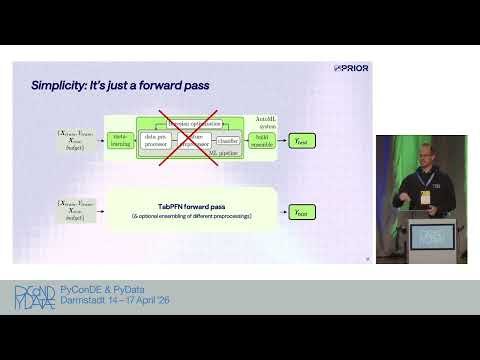

In [1]:
# Vídeo: a revolução dos modelos pré-treinados para dados em tabela
from IPython.display import YouTubeVideo

YouTubeVideo("QvU7w_rwXh8", width=700, height=394)


## O que é o Mitra, sem jargão

Na parte 1 você viu o TabPFN: um modelo que já foi treinado em milhões de tabelas **inventadas por computador** e que, na hora de usar, apenas lê a sua tabela de treino como contexto e responde. Ele não aprende com o seu dado.

O Mitra segue a mesma ideia e vai um passo adiante. Se o modelo não aprende com o seu dado, a pergunta importante deixa de ser "qual arquitetura" e passa a ser "que tipo de tabela inventada devo usar no treinamento". O Mitra é o trabalho que investigou isso: testou tipos de dados sintéticos (o que o paper chama de *priors*), escolheu uma mistura que faz o modelo generalizar melhor e treinou um modelo novo com ela. Os pesos são abertos e podem ser baixados por qualquer pessoa.

Quem faz o quê no código: o **AutoGluon** é o orquestrador, ele cuida das partes chatas (tipos de coluna, conversão de texto para número, validação interna, salvar o modelo em disco); o **Mitra** é o modelo em si. Você diz "treine só o Mitra" e o AutoGluon faz o resto. E o `fit` continua não treinando pesos: o seu treino entra como contexto, no modo que se chama *zero-shot*. Existe também o modo `fine_tune=True`, que aí sim ajusta os pesos do modelo, e que fica para outra aula.

O que observar: as métricas são as mesmas do notebook anterior (ROC-AUC e F1 na classificação; RMSE, MAE e R² na regressão), sobre **a mesma divisão de treino e teste**. A coluna de tempo é onde este notebook mais ensina: modelo pré-treinado tem `fit` barato e `predict` caro, e em CPU esse preço aparece multiplicado.


## Passo 0: instalar o que falta

O Mitra mora dentro de um pacote opcional do AutoGluon. Esta instalação é grande (ela traz o PyTorch junto), então no Colab pode levar alguns minutos: é normal ver a célula demorar.

Se depois dela aparecer um erro dizendo que um módulo não foi encontrado, reinicie o ambiente (*Ambiente de execução → Reiniciar sessão*) e comece de novo pela célula de imports.


In [2]:
!pip install "autogluon.tabular[mitra]==1.6.3"


  Using cached autogluon.tabular-0.0.16b20210206-py3-none-any.whl.metadata (7.7 kB)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/24.6 MB ? eta -:--:--

     ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/24.6 MB 4.8 MB/s eta 0:00:06

     ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/24.6 MB 3.3 MB/s eta 0:00:08

     ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/24.6 MB 3.2 MB/s eta 0:00:08

...

 /

 -

 \

 error


  error: subprocess-exited-with-error
  
  × installing build dependencies for scipy did not run successfully.
  │ exit code: 1
  ╰─> [67 lines of output]
      Ignoring numpy: markers 'python_version == "3.5" and platform_system != "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.6" and platform_system != "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.7" and platform_system != "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.5" and platform_system == "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.6" and platform_system == "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version == "3.7" and platform_system == "AIX"' don't match your environment
      Ignoring numpy: markers 'python_version >= "3.8" and platform_system == "AIX"' don't match your environment
        Using cached setuptools-84.0.0-py3-none

In [3]:
import shutil
import time

import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

# A mesma semente do primeiro notebook: a divisão de treino e teste sai igual,
# então as tabelas dos dois notebooks podem ser comparadas.
RANDOM_STATE = 42
TEST_SIZE = 0.25

print("✅ tudo importado")


✅ tudo importado


# Parte 1: classificação

Mesma tabela do notebook anterior: 569 exames de tumor, 30 medidas, e queremos prever a coluna `target`.

Aviso de tempo: em CPU, treinar e prever com o Mitra leva **minutos**, não segundos. O log que aparece é o AutoGluon contando o que está fazendo.


In [4]:
# Passo 1: carregar a tabela
data = load_breast_cancer(as_frame=True).frame

print("linhas e colunas:", data.shape)
print("a coluna que queremos prever é 'target':", data["target"].unique())


linhas e colunas: (569, 31)
a coluna que queremos prever é 'target': [0 1]


In [5]:
# Passo 2: separar em treino e teste (igual ao primeiro notebook)
train, test = train_test_split(
    data, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=data["target"]
)

X_train, y_train = train.drop(columns="target"), train["target"]
X_test, y_test = test.drop(columns="target"), test["target"]

print(f"treino: {X_train.shape[0]} exames | teste: {X_test.shape[0]} exames")

clf_results = []


treino: 426 exames | teste: 143 exames


In [6]:
# Passo 3 (modelo tradicional): Random Forest, para servir de comparação
model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

start = time.time()
model.fit(X_train, y_train)
fit_s = time.time() - start

start = time.time()
proba = model.predict_proba(X_test)[:, 1]
predict_s = time.time() - start

clf_results.append({
    "model": "Random Forest",
    "roc_auc": roc_auc_score(y_test, proba),
    "f1_macro": f1_score(y_test, (proba > 0.5).astype(int), average="macro"),
    "fit_s": round(fit_s, 2),
    "predict_s": round(predict_s, 2),
    "total_s": round(fit_s + predict_s, 2),
})
print(clf_results[-1])


{'model': 'Random Forest', 'roc_auc': 0.9948637316561845, 'f1_macro': 0.9546703296703296, 'fit_s': 0.52, 'predict_s': 0.02, 'total_s': 0.54}


In [7]:
# Passo 4 (modelo pré-treinado): Mitra, chamado pelo AutoGluon
# O AutoGluon guarda o modelo treinado nesta pasta. Se a pasta já existir, ele reaproveita
# o modelo de lá em vez de treinar de novo, e o tempo medido sairia errado. Por isso apagamos.
shutil.rmtree("modelo_mitra_classificacao", ignore_errors=True)

# hyperparameters diz o que treinar: só o Mitra. fine_tune=False = modo zero-shot.
predictor = TabularPredictor(label="target", path="modelo_mitra_classificacao")

start = time.time()
predictor.fit(train, hyperparameters={"MITRA": {"fine_tune": False}})
fit_s = time.time() - start

start = time.time()
proba = predictor.predict_proba(test).iloc[:, 1].to_numpy()   # coluna 1 = classe positiva
predict_s = time.time() - start

clf_results.append({
    "model": "Mitra (AutoGluon)",
    "roc_auc": roc_auc_score(y_test, proba),
    "f1_macro": f1_score(y_test, (proba > 0.5).astype(int), average="macro"),
    "fit_s": round(fit_s, 2),
    "predict_s": round(predict_s, 2),
    "total_s": round(fit_s + predict_s, 2),
})
print(clf_results[-1])


Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 18 21:54:43 UTC 2026
CPU Count:          12
Pytorch Version:    2.13.0+cu130
CUDA Version:       CUDA is not available
Memory Avail:       13.77 GB / 19.53 GB (70.5%)
Disk Space Avail:   848.92 GB / 1006.85 GB (84.3%)


No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and the one to use for benchmark comparisons. New in v1.6: far better than 'best' on datasets <100000 samples by using Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: Nori, TabICLv2, and TabDPT-Turbo. Every model is free for commercial use. Requires `pip install autogluon.tabular[tabarena]`.
	presets='noncommercial': New in v1.6: 'extreme' plus TabPFN-3, a frontier tabular foundation model created by Prior Labs. Stronger still, but commercial use requires a TabPFN-3 license: https://docs.priorlabs.ai/models#tabpfn-model-license
	presets='best'     : Use this if you do not have a GPU. Maximize accuracy. Use in competi

Beginning AutoGluon training ...


AutoGluon will save models to "/home/fabricio/.hermes/cache/scratch/tfm-cookbook/modelo_mitra_classificacao"


...

AutoGluon training complete, total runtime = 182.7s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 0.9 rows/s (86 batch size)


Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (86 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/fabricio/.hermes/cache/scratch/tfm-cookbook/modelo_mitra_classificacao")


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'model': 'Mitra (AutoGluon)', 'roc_auc': 0.9983228511530399, 'f1_macro': 0.9702455264253016, 'fit_s': 184.62, 'predict_s': 111.81, 'total_s': 296.43}


### Como ler isso

`roc_auc` perto de 1,0 significa que o modelo ordena bem os exemplos. `f1_macro` mistura acerto e erro nas duas classes. E olhe a diferença entre `fit_s` e `predict_s`: o Mitra quase não gasta tempo "aprendendo", porque ele não aprende, ele lê o contexto. O tempo vai todo para a previsão.


In [8]:
# Passo 5: a tabela comparativa da classificação
clf_table = pd.DataFrame(clf_results).set_index("model").sort_values("roc_auc", ascending=False)
clf_table.round(4)


,roc_auc,f1_macro,fit_s,predict_s,total_s
model,,,,,
Mitra (AutoGluon),0.9983,0.9702,184.62,111.81,296.43
Random Forest,0.9949,0.9547,0.52,0.02,0.54


# Parte 2: regressão

Agora o alvo é um número: o preço mediano de casas na Califórnia. Mesma tabela e mesma divisão do primeiro notebook (2 500 linhas sorteadas com a mesma semente).

Se estiver em CPU, prepare-se: esta é a parte mais lenta do notebook.


In [9]:
# Passo 6: carregar a tabela
housing = fetch_california_housing(as_frame=True).frame
data = housing.rename(columns={"MedHouseVal": "target"}).sample(n=2500, random_state=RANDOM_STATE)

print("linhas e colunas:", data.shape)


linhas e colunas: (2500, 9)


In [10]:
# Passo 7: separar em treino e teste
train, test = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_train, y_train = train.drop(columns="target"), train["target"]
X_test, y_test = test.drop(columns="target"), test["target"]

print(f"treino: {X_train.shape[0]} casas | teste: {X_test.shape[0]} casas")

reg_results = []


treino: 1875 casas | teste: 625 casas


In [11]:
# Passo 8 (modelo tradicional): Random Forest
model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)

start = time.time()
model.fit(X_train, y_train)
fit_s = time.time() - start

start = time.time()
y_pred = model.predict(X_test)
predict_s = time.time() - start

reg_results.append({
    "model": "Random Forest",
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "mae": float(mean_absolute_error(y_test, y_pred)),
    "r2": float(r2_score(y_test, y_pred)),
    "fit_s": round(fit_s, 2),
    "predict_s": round(predict_s, 2),
    "total_s": round(fit_s + predict_s, 2),
})
print(reg_results[-1])


{'model': 'Random Forest', 'rmse': 0.5822454236825265, 'mae': 0.38981209269333367, 'r2': 0.7393671641683419, 'fit_s': 1.91, 'predict_s': 0.04, 'total_s': 1.95}


In [12]:
# Passo 9 (modelo pré-treinado): Mitra na regressão
shutil.rmtree("modelo_mitra_regressao", ignore_errors=True)

predictor = TabularPredictor(label="target", path="modelo_mitra_regressao")

start = time.time()
predictor.fit(train, hyperparameters={"MITRA": {"fine_tune": False}})
fit_s = time.time() - start

start = time.time()
y_pred = predictor.predict(test).to_numpy()
predict_s = time.time() - start

reg_results.append({
    "model": "Mitra (AutoGluon)",
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "mae": float(mean_absolute_error(y_test, y_pred)),
    "r2": float(r2_score(y_test, y_pred)),
    "fit_s": round(fit_s, 2),
    "predict_s": round(predict_s, 2),
    "total_s": round(fit_s + predict_s, 2),
})
print(reg_results[-1])


Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 18 21:54:43 UTC 2026
CPU Count:          12
Pytorch Version:    2.13.0+cu130
CUDA Version:       CUDA is not available
Memory Avail:       13.34 GB / 19.53 GB (68.3%)
Disk Space Avail:   848.64 GB / 1006.85 GB (84.3%)


No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and the one to use for benchmark comparisons. New in v1.6: far better than 'best' on datasets <100000 samples by using Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: Nori, TabICLv2, and TabDPT-Turbo. Every model is free for commercial use. Requires `pip install autogluon.tabular[tabarena]`.
	presets='noncommercial': New in v1.6: 'extreme' plus TabPFN-3, a frontier tabular foundation model created by Prior Labs. Stronger still, but commercial use requires a TabPFN-3 license: https://docs.priorlabs.ai/models#tabpfn-model-license
	presets='best'     : Use this if you do not have a GPU. Maximize accuracy. Use in competi

Beginning AutoGluon training ...


AutoGluon will save models to "/home/fabricio/.hermes/cache/scratch/tfm-cookbook/modelo_mitra_regressao"


...

	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 269.75s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 2.7 rows/s (375 batch size)


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/fabricio/.hermes/cache/scratch/tfm-cookbook/modelo_mitra_regressao")


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'model': 'Mitra (AutoGluon)', 'rmse': 0.49640474764751913, 'mae': 0.3392104215102844, 'r2': 0.8105525278109944, 'fit_s': 269.91, 'predict_s': 171.19, 'total_s': 441.1}


### Como ler isso

`rmse` e `mae` são erros: menor é melhor. `r2` é a fração da variação explicada: maior é melhor. O ponto aqui não é decorar quem ganhou, e sim reparar que **o custo mudou de lugar**: o modelo tradicional gasta tempo no `fit`; o modelo pré-treinado gasta no `predict`.


In [13]:
# Passo 10: a tabela comparativa da regressão
reg_table = pd.DataFrame(reg_results).set_index("model").sort_values("rmse")
reg_table.round(4)


,rmse,mae,r2,fit_s,predict_s,total_s
model,,,,,,
Mitra (AutoGluon),0.4964,0.3392,0.8106,269.91,171.19,441.10
Random Forest,0.5822,0.3898,0.7394,1.91,0.04,1.95


## Para levar

O Mitra não é um modelo que você treina: é um modelo que já veio treinado de outro lugar e que lê o seu treino como contexto. O papel do AutoGluon é tirar do seu caminho tudo o que não é modelagem (encoding, validação, salvar em disco), e o papel do `hyperparameters` é dizer qual modelo do portfólio usar.

Três cuidados antes de tirar conclusão: **uma divisão só de treino e teste não decide qual modelo é melhor** (repita com sementes diferentes e reporte média e desvio); **tempo de CPU não é tempo de GPU**; e o modelo pré-treinado **não é resposta universal** — quando a tabela cresce (acima de ~10 000 linhas), o AutoGluon pula o Mitra e usa os modelos clássicos do portfólio.

**Próximo passo:** trocar `fine_tune=False` por `fine_tune=True` e comparar com o modo zero-shot. É aí que o modelo genérico vira modelo do seu domínio.

### Referências

**Mitra**
Zhang, X., Maddix, D. C., Yin, J., Erickson, N., Ansari, A. F., Han, B., Zhang, S., Akoglu, L., Faloutsos, C., Mahoney, M. W., Hu, C., Rangwala, H., Karypis, G., & Wang, B. (2025). *Mitra: Mixed Synthetic Priors for Enhancing Tabular Foundation Models.* NeurIPS 2025. arXiv:2510.21204.

**AutoGluon (a ferramenta que chama o Mitra)**
Erickson, N., Mueller, J., Shirkov, A., Zhang, H., Larroy, P., Li, M., & Smola, A. (2020). *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data.* arXiv:2003.06505.

**TabPFN (o modelo do notebook 1)**
Hollmann, N., Müller, S., Purucker, L., Krishnakumar, A., Körfer, M., Hoo, S. B., Schirrmeister, R. T., & Hutter, F. (2025). *Accurate predictions on small data with a tabular foundation model.* **Nature** 637, 319–326. DOI: 10.1038/s41586-024-08328-6. Preprint: arXiv:2402.12884.

**Código e documentação**
https://auto.gluon.ai/stable/tutorials/tabular/tabular-foundational-models.html · https://huggingface.co/autogluon/mitra-classifier

```bibtex
@inproceedings{zhang2025mitra,
  title     = {Mitra: Mixed Synthetic Priors for Enhancing Tabular Foundation Models},
  author    = {Zhang, Xiyuan and Maddix, Danielle C. and Yin, Junming and Erickson, Nick and
               Ansari, Abdul Fatir and Han, Boran and Zhang, Shuai and Akoglu, Leman and
               Faloutsos, Christos and Mahoney, Michael W. and Hu, Cuixiong and
               Rangwala, Huzefa and Karypis, George and Wang, Bernie},
  booktitle = {Advances in Neural Information Processing Systems (NeurIPS)},
  year      = {2025},
  eprint    = {2510.21204},
  archivePrefix = {arXiv}
}

@article{erickson2020autogluon,
  title   = {AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data},
  author  = {Erickson, Nick and Mueller, Jonas and Shirkov, Alexander and Zhang, Hang and
             Larroy, Pedro and Li, Mu and Smola, Alex},
  journal = {arXiv preprint arXiv:2003.06505},
  year    = {2020}
}

@article{hollmann2025tabpfn,
  title   = {Accurate predictions on small data with a tabular foundation model},
  author  = {Hollmann, Noah and M{\"u}ller, Samuel and Purucker, Lennart and
             Krishnakumar, Arjun and K{\"o}rfer, Max and Hoo, Shi Bin and
             Schirrmeister, Robin Tibor and Hutter, Frank},
  journal = {Nature},
  volume  = {637},
  pages   = {319--326},
  year    = {2025},
  doi     = {10.1038/s41586-024-08328-6}
}
```

Esta é a versão didática da série. Existe também a versão completa, `cookbooks/02_mitra_autogluon_cookbook.ipynb`, com o protocolo experimental detalhado (impressão digital dos splits, warm-up, leaderboard do AutoGluon e as mesmas tabelas em CSV).
